# Amacrine Cells (ACs) Neuromodulation, Preprocessing

- notebook based on the djimaging tutorial written by Jonathan Oesterle
- data was 2PM Ca2+ imaging from amacrine cell dendrites (GAD65:Cre x Ai96GCampf6)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Access to djimaging database

## Define paths

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [14]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2026-09-28 14:58:36,875][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2026-09-28 14:58:38,447][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Create or load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [15]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

In [16]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

## ERD

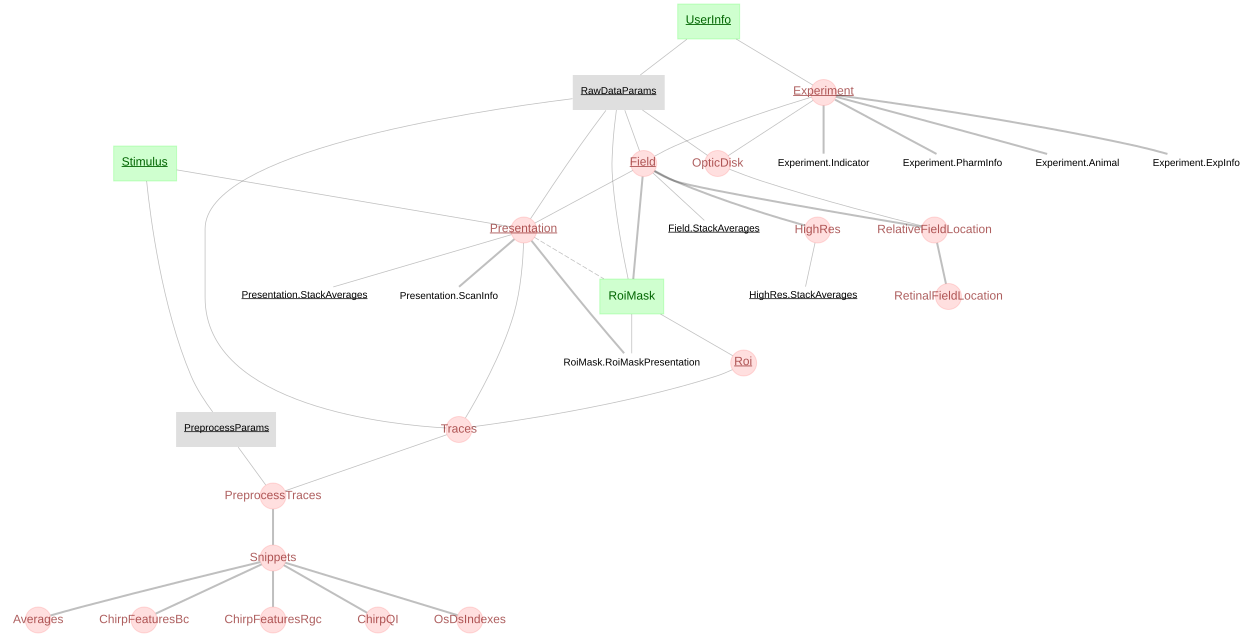

In [17]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    display(dj.ERD(schema))

# Upload user

In [16]:
userinfo = {
    'experimenter': 'Salomon', # Replace this if you want to use your own data
    'data_dir': '/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/', # Replace this if you want to use your own data
    'datatype_loc': 0,
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 4,
    'stimulus_loc': 5,
    'cond1_loc': 3,
    'cond2_loc': 6,
    'cond3_loc': 7,
}

assert os.path.isdir(userinfo['data_dir'])

In [17]:
UserInfo().upload_user(userinfo)
UserInfo()

Information for `Salomon` already uploaded.
If you want to change the user entry, delete the existing one first and upload the user again.


experimenter name of the experimenter,"data_dir path to header file, used for computed tables",field_loc string location for field,stimulus_loc string location for stimulus,animal_loc string location for number of animal (e.g. M1),datatype_loc string location for datatype (e.g. SMP),region_loc string location for region (e.g. LR or RR),cond1_loc string location for condition 1 (e.g. pharmacological),cond2_loc string location for condition 2 (e.g. pharmacological),cond3_loc string location for condition 3 (e.g. pharmacological),opticdisk_alias alias(es) for optic disk (separated by _),outline_alias alias(es) for retinal outline / edge (separated by _),highres_alias alias(es) for high resolution stack,mask_alias Ordered alias(es) for field roi mask (separated by _),pre_data_dir directory for h5 data files,raw_data_dir directory for smp and smh data files,"data_stack_name main data channel, e.g. OGB-1","alt_stack_name alternative data channel, e.g. SR101"
Salomon,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/,4,5,1,0,2,3,6,7,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1


In [18]:
# Plot the data files in the selected folder
UserInfo().plot1(key=None, show_pre=False, show_raw=False, show_header=True)

/:  [2 files]
20250526/:  [0 files]
    1/:  [1 files]
        20250526_left.ini
        Pre/:  [0 files]
        ROIs/:  [36 files]
        Raw/:  [112 files]
20250612/:  [3 files]
    1/:  [2 files]
        Raw/:  [2 files]
    2/:  [4 files]
        20250612_right.ini
        ROIs/:  [43 files]
        Raw/:  [126 files]
20250710/:  [2 files]
    1/:  [3 files]
        20250710_left.ini
        ROIs/:  [18 files]
        Raw/:  [44 files]
    2/:  [1 files]
        20250710_right.ini
        ROIs/:  [9 files]
        Raw/:  [24 files]
20250908/:  [0 files]
    2/:  [1 files]
        20250908_right.ini
        Pre/:  [0 files]
        ROIs/:  [48 files]
        Raw/:  [126 files]
20251023/:  [0 files]
    1/:  [1 files]
        20251023_left.ini
        Pre/:  [0 files]
        ROIs/:  [12 files]
        Raw/:  [32 files]
    2/:  [1 files]
        20251023_right.ini
        Pre/:  [0 files]
        ROIs/:  [36 files]
        Raw/:  [96 files]
20251119/:  [0 files]
    2/:  [1 files]

In [19]:
RawDataParams().add_default()
RawDataParams().update1({"experimenter": "Salomon", "raw_id": 1, "from_raw_data": 1, "igor_roi_masks":"init"})
RawDataParams()

experimenter name of the experimenter,raw_id unique param set id,from_raw_data Load raw smp data (1) or h5 data (0),compute_from_stack Compute traces from stack. Otherwise try to import Igor traces.,include_artifacts automatically exclude all ROIs with artifacts?,trace_precision Compute traces with either line precision or pixel precision?,trigger_precision Compute triggers with either line precision or pixel precision?,"igor_roi_masks Either load or ignore existing ROI masks, e.g. from Igor"
Salomon,1,1,1,0,line,line,init


# Populate experimental data

## Experiments

In [20]:
Experiment().rescan_filesystem(verboselvl=2)
Experiment()

Scanning for experimenter: Salomon
	header_path: /gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1
		header_name: 20250526_left.ini
		Already present: {'experimenter': 'Salomon', 'date': datetime.datetime(2025, 5, 26, 0, 0), 'exp_num': 1}
	header_path: /gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/2
		header_name: 20251023_right.ini
		Already present: {'experimenter': 'Salomon', 'date': datetime.datetime(2025, 10, 23, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/1
		header_name: 20251023_left.ini
		Already present: {'experimenter': 'Salomon', 'date': datetime.datetime(2025, 10, 23, 0, 0), 'exp_num': 1}
	header_path: /gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2
		header_name: 20250612_right.ini
		Already present: {'experimenter': 'Salomon', 'date': datetime.datetime(2025, 6, 12, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250710/2
		header_name: 20250710_right.ini
		

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,header_path path to header file,header_name name of header file
Salomon,2025-05-26,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/,20250526_left.ini
Salomon,2025-06-12,2,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/,20250612_right.ini
Salomon,2025-07-10,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250710/1/,20250710_left.ini
Salomon,2025-07-10,2,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250710/2/,20250710_right.ini
Salomon,2025-09-08,2,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250908/2/,20250908_right.ini
Salomon,2025-10-23,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/1/,20251023_left.ini
Salomon,2025-10-23,2,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/2/,20251023_right.ini
Salomon,2025-11-19,2,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251119/2/,20251119_right.ini


## Fields

In [21]:
Field().rescan_filesystem(verboselvl=2)

Found 52 files in 8 fields for key={'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'XY1', 'region': 'LR', 'cond1': 'd', 'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'XY2', 'region': 'LR', 'cond1': 'd', 'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}`
	Skipping field `{'field': 'XY3', 'region': 'LR', 'cond1': 'n', 'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}` because it already exists
	Skipping field `{'field': 'XY4', 'region': 'LR', 'cond1': 'n', 'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}` because it already exists
	Skipping field `{'field': 'XY5', 'region': 'LR', 'cond1': 'v', 'experimenter': 'Salomon', 'date': datetime.date(2025, 5, 26), 'exp_num': 1, 'raw_id': 1}` because it already exists
	Skipping field `{'fiel

/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_n_0-21-zoom.smp: File M1_RR_n_0-21-zoom.smp does not contain a valid stimulus field: {'field': '0-21-zoom', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'n', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_v_highres.smp: File M1_RR_v_highres.smp does not contain a valid stimulus field: {'field': 'highres', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'v', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")


	Skipping field `{'field': 'XY6', 'region': 'RR', 'cond1': 'd', 'experimenter': 'Salomon', 'date': datetime.date(2025, 9, 8), 'exp_num': 2, 'raw_id': 1}` because it already exists
	Skipping field `{'field': 'XY7', 'region': 'RR', 'cond1': 'n', 'experimenter': 'Salomon', 'date': datetime.date(2025, 9, 8), 'exp_num': 2, 'raw_id': 1}` because it already exists
	Skipping field `{'field': 'XY8', 'region': 'RR', 'cond1': 'n', 'experimenter': 'Salomon', 'date': datetime.date(2025, 9, 8), 'exp_num': 2, 'raw_id': 1}` because it already exists
Found 14 files in 2 fields for key={'experimenter': 'Salomon', 'date': datetime.date(2025, 10, 23), 'exp_num': 1, 'raw_id': 1}
	Skipping field `{'field': 'XY7', 'region': 'LR', 'cond1': 't', 'experimenter': 'Salomon', 'date': datetime.date(2025, 10, 23), 'exp_num': 1, 'raw_id': 1}` because it already exists
	Skipping field `{'field': 'XY8', 'region': 'LR', 'cond1': 't', 'experimenter': 'Salomon', 'date': datetime.date(2025, 10, 23), 'exp_num': 1, 'raw_id':

/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a valid stimulus field: {'field': 'zstack', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'XY1', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")


	Adding field: `{'field': '500glutamte', 'region': 'RR', 'cond1': 'XY2', 'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': '500glutamte', 'region': 'RR', 'cond1': 'XY3', 'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'XY4', 'region': 'RR', 'cond1': 't', 'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1}`
	Adding field: `{'field': 'XY5', 'region': 'RR', 'cond1': 't', 'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1}`


In [14]:
Field() & {"date": datetime.date(2025, 5, 26)}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),field_data_file info extracted from which file?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact Number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um
Salomon,2025-05-26,1,1,XY3,LR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_chirp_C1.smp,-313.72,-8010.5,-26996.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY4,LR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_chirp_C1.smp,-313.72,-8010.5,-27014.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY5,LR,v,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_v_XY5_chirp_C1.smp,-231.68,-8170.3,-27028.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY6,LR,v,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_v_XY6_chirp_C1.smp,-231.68,-8170.3,-27014.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY7,LR,t,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_t_XY7_chirp_C1.smp,-871.12,-8220.8,-26970.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY8,LR,t,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_t_XY8_chirp_C1.smp,-871.12,-8220.8,-26961.0,xy,3,64,64,1,6,10,1.71875,nan


### Delete faulty fields

- during some recordings mistakes happened, these fields will be collected and deleted before any ROIs are created to save time later in the analysis
- behind every field key a comment is written why this field specifically will be deleted

In [22]:
# Define faulty field entries
bad_fields = [
    dict(date=datetime.date(2025, 5, 26), field='XY2', region='LR'), # On 26.05.2025, field XY2 could not be recorded with DETANO condition
    dict(date=datetime.date(2025, 5, 26), field='XY1', region='LR'), # On 26.05.2025, field XY1 was not in the same imaging plane for DETA/NO condition
    dict(date=datetime.date(2025, 9, 8), field='XY5', region='RR')   # On 09.08.2025 field XY5 had a strong drift in the Z-plane
]
bad_fields

[{'date': datetime.date(2025, 5, 26), 'field': 'XY2', 'region': 'LR'},
 {'date': datetime.date(2025, 5, 26), 'field': 'XY1', 'region': 'LR'},
 {'date': datetime.date(2025, 9, 8), 'field': 'XY5', 'region': 'RR'}]

In [23]:
# Delete faulty fields
for key in bad_fields:
    print(f"Deleting faulty entry: {key}")
    (Field() & key).delete()

[2026-03-04 10:05:26,523][INFO]: Deleting 3 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field__stack_averages`
[2026-03-04 10:05:26,552][INFO]: Deleting 1 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field`


Deleting faulty entry: {'date': datetime.date(2025, 5, 26), 'field': 'XY2', 'region': 'LR'}


Commit deletes? [yes, No]:  yes


[2026-03-04 10:05:29,031][INFO]: Delete committed.
[2026-03-04 10:05:29,084][INFO]: Deleting 3 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field__stack_averages`
[2026-03-04 10:05:29,113][INFO]: Deleting 1 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field`


Deleting faulty entry: {'date': datetime.date(2025, 5, 26), 'field': 'XY1', 'region': 'LR'}


Commit deletes? [yes, No]:  yes


[2026-03-04 10:05:30,254][INFO]: Delete committed.
[2026-03-04 10:05:30,306][INFO]: Deleting 3 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field__stack_averages`
[2026-03-04 10:05:30,334][INFO]: Deleting 1 rows from `ageuler_fsalomon_neuromodulation_ac`.`__field`


Deleting faulty entry: {'date': datetime.date(2025, 9, 8), 'field': 'XY5', 'region': 'RR'}


Commit deletes? [yes, No]:  yes


[2026-03-04 10:05:31,501][INFO]: Delete committed.


In [24]:
Field()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),field_data_file info extracted from which file?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact Number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um
Salomon,2025-05-26,1,1,XY3,LR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_chirp_C1.smp,-313.72,-8010.5,-26996.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY4,LR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_chirp_C1.smp,-313.72,-8010.5,-27014.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY5,LR,v,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_v_XY5_chirp_C1.smp,-231.68,-8170.3,-27028.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY6,LR,v,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_v_XY6_chirp_C1.smp,-231.68,-8170.3,-27014.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY7,LR,t,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_t_XY7_chirp_C1.smp,-871.12,-8220.8,-26970.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-05-26,1,1,XY8,LR,t,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_t_XY8_chirp_C1.smp,-871.12,-8220.8,-26961.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-06-12,2,1,0-21-zoom,RR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/Raw/M1_RR_n_0-21-zoom_highres.smp,190.2,-7741.5,-26987.0,xy,3,512,512,1,56,84,0.664993,nan
Salomon,2025-06-12,2,1,XY,RR,d,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/Raw/M1_RR_d_XY_chirp_Z4.smp,-715.04,-7161.6,-26961.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-06-12,2,1,XY10,RR,n,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/Raw/M1_RR_n_XY10_chirp_C1.smp,190.2,-7741.5,-26987.0,xy,3,64,64,1,6,10,1.71875,nan
Salomon,2025-06-12,2,1,XY8,RR,t,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/Raw/M1_RR_t_XY8_chirp_C1.smp,314.92,-8271.0,-26977.0,xy,3,64,64,1,6,10,1.71875,nan


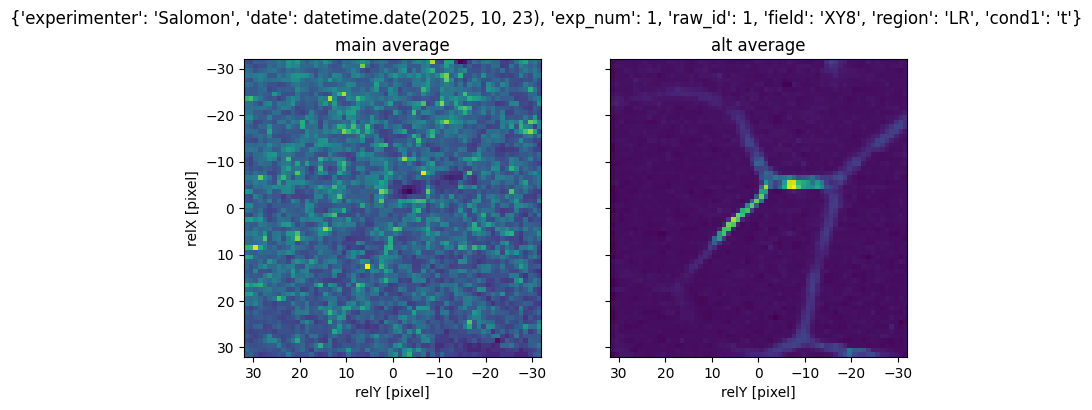

In [25]:
# If you call plot1 on a djimaging table, it will plot the given key.
# If you pass key=None or no key it will pick a key at random.
# This is implemented for most core tables and can be useful to get a quick impression of the data.
(Field() & {"date": datetime.date(2025, 10, 23)}).plot1()

## Stimuli

### Add default stimuli

In [26]:
# To compute receptive fields, the noise stimulus trace must be loaded and set!
import h5py

with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

In [27]:
Stimulus().add_nostim(skip_duplicates=True)
Stimulus().add_chirp(spatialextent=1000, stim_name='gChirp', alias="chirp_gchirp_globalchirp", skip_duplicates=True)
Stimulus().add_chirp(spatialextent=100, stim_name='lChirp', alias="lchirp_localchirp", skip_duplicates=True)
Stimulus().add_noise(stim_name='noise', pix_n_x=20, pix_n_y=15, pix_scale_x_um=30, pix_scale_y_um=30, stim_trace=noise_stimulus, skip_duplicates=True)
Stimulus().add_movingbar(skip_duplicates=True)

/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


In [28]:
# Add custom stimulus if needed
# Stimulus().add_stimulus(stim_name='my_stimulus', alias="stimname_stimnameabbr_alternativename", isrepeated=True, ntrigger_rep=6,
#                         trial_info=[1, 2, 3, 4, 5, 6], skip_duplicates=True)

In [29]:
Stimulus()

stim_name Unique string identifier,"alias Strings (_ seperator) to identify this stimulus, not case sensitive!",stim_family To group stimuli (e.g. gChirp and lChirp) for downstream processing,framerate framerate in Hz,isrepeated Is the stimulus repeated? Used for snippets,ntrigger_rep Number of triggers (per repetition),stim_path Path to hdf5 file containing numerical array and info about stim,commit_id Commit id corresponding to stimulus entry in GitHub repo,stim_hash QDSpy hash,"trial_info trial information, e.g. directions of moving bar",stim_trace array of stimulus if available,"stim_dict stimulus information dictionary, contains e.g. spatial extent",snippet_base_dt Time used for snippet baseline estimation
gChirp,chirp_gchirp_globalchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
lChirp,lchirp_localchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
movingbar,mb_mbar_bar_movingbar,movingbar,0.0166667,1,1,,,,=BLOB=,=BLOB=,=BLOB=,nan
noise,dn_noise_dn30m_noise30m,noise,5.0,0,1500,,,,=BLOB=,=BLOB=,=BLOB=,nan
nostim,nostim_none,,0.0,0,0,,,,=BLOB=,=BLOB=,=BLOB=,nan


### Presentations

In [30]:
Presentation().populate(processes=20, display_progress=True)

Processes:   0%|          | 0/87 [00:00<?, ?it/s]/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a valid stimulus field: {'field': 'zstack', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'XY1', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a valid stimulus field: {'field': 'zstack', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'XY1', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a va

{'success_count': 87, 'error_list': []}

In [31]:
Presentation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),pres_data_file path to file (e.g. h5 file),triggertimes triggertimes in each presentation,trigger_valid Are triggers as expected (1) or not (0)?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um,nframes number of pixels in time
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_chirp_C1.smp,=BLOB=,1,-313.72,-8010.5,-26996.0,xy,3,64,64,1,6,10,1.71875,nan,1658
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,DETANO,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_chirp_DETANO.smp,=BLOB=,1,-313.6,-8007.7,-26995.0,xy,3,64,64,1,6,10,1.71875,nan,1643
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_mb_C1.smp,=BLOB=,1,-313.72,-8010.5,-26996.0,xy,3,64,64,1,6,10,1.71875,nan,1200
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,DETANO,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_mb_DETANO.smp,=BLOB=,1,-311.72,-8007.7,-26996.0,xy,3,64,64,1,6,10,1.71875,nan,1044
Salomon,2025-05-26,1,1,XY3,LR,n,noise,C1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_dn_C1.smp,=BLOB=,1,-313.72,-8010.5,-26996.0,xy,3,64,64,1,6,10,1.71875,nan,2647
Salomon,2025-05-26,1,1,XY3,LR,n,noise,DETANO,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY3_dn_DETANO.smp,=BLOB=,1,-313.6,-8007.7,-26995.0,xy,3,64,64,1,6,10,1.71875,nan,2591
Salomon,2025-05-26,1,1,XY4,LR,n,gChirp,C1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_chirp_C1.smp,=BLOB=,1,-313.72,-8010.5,-27014.0,xy,3,64,64,1,6,10,1.71875,nan,1556
Salomon,2025-05-26,1,1,XY4,LR,n,gChirp,DETANO,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_chirp_DETANO.smp,=BLOB=,1,-313.52,-8007.7,-27019.0,xy,3,64,64,1,6,10,1.71875,nan,1572
Salomon,2025-05-26,1,1,XY4,LR,n,movingbar,C1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_mb_C1.smp,=BLOB=,1,-313.72,-8010.5,-27014.0,xy,3,64,64,1,6,10,1.71875,nan,1038
Salomon,2025-05-26,1,1,XY4,LR,n,movingbar,DETANO,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_XY4_mb_DETANO.smp,=BLOB=,1,-313.52,-8007.7,-27019.0,xy,3,64,64,1,6,10,1.71875,nan,1090


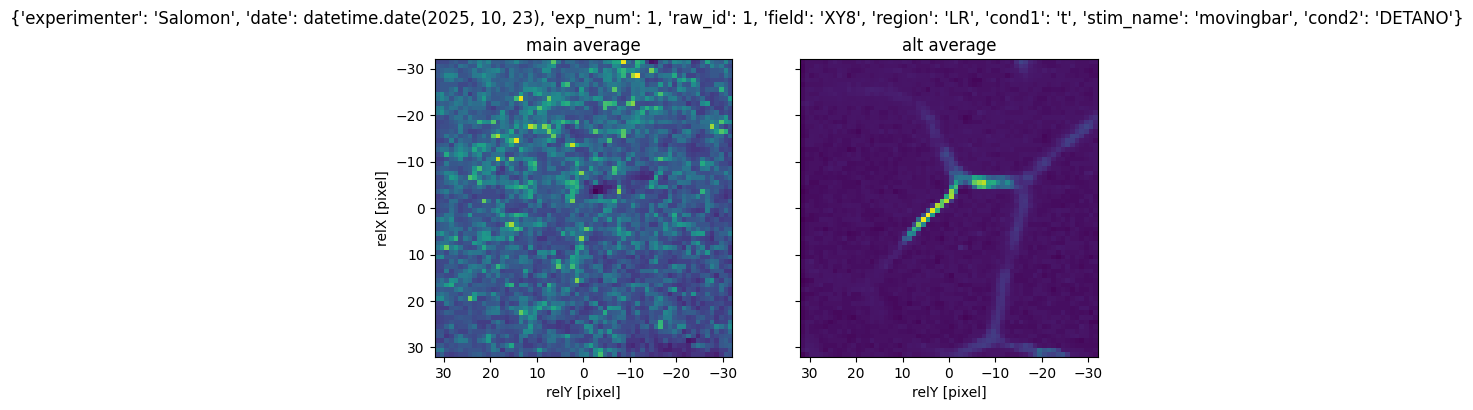

In [32]:
(Presentation() & {"date": datetime.date(2025, 10, 23), "field": "XY8"}).plot1()

# AutoROIs
- generate regions of interest (ROIs) automatically using AutoROI GUI

## Scan recording fields for ROIs
- if no ROIs could be detected for the field, they will be generated later down the code

In [37]:
# If you have save some of you AutoROIs ROI masks you can load them here.
RoiMask().rescan_filesystem(verboselvl=2)
RoiMask()

No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 6, 12), 'exp_num': 2, 'raw_id': 1, 'field': '0-21-zoom', 'region': 'RR', 'cond1': 'n'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY1'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY2'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY3'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': 'XY4', 'region': 'RR', 'cond1': 't'}
Adding 6 ROI masks for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'fi

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_mask ROI mask for recording field
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,=BLOB=
Salomon,2025-05-26,1,1,XY4,LR,n,gChirp,C1,=BLOB=
Salomon,2025-05-26,1,1,XY5,LR,v,gChirp,C1,=BLOB=
Salomon,2025-05-26,1,1,XY6,LR,v,gChirp,C1,=BLOB=
Salomon,2025-05-26,1,1,XY7,LR,t,gChirp,C1,=BLOB=
Salomon,2025-05-26,1,1,XY8,LR,t,gChirp,C1,=BLOB=
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,=BLOB=
Salomon,2025-06-12,2,1,XY10,RR,n,gChirp,C1,=BLOB=
Salomon,2025-06-12,2,1,XY8,RR,t,gChirp,C1,=BLOB=
Salomon,2025-06-12,2,1,XY9,RR,v,gChirp,C1,=BLOB=


In [38]:
# Find all the fields that still require a ROI mask.
missing_fields = RoiMask().list_missing_field()
missing_fields

[{'experimenter': 'Salomon',
  'date': datetime.date(2025, 11, 19),
  'exp_num': 2,
  'raw_id': 1,
  'field': 'XY4',
  'region': 'RR',
  'cond1': 't'}]

In [39]:
field_key = missing_fields.pop()  # Pick one field
field_key

{'experimenter': 'Salomon',
 'date': datetime.date(2025, 11, 19),
 'exp_num': 2,
 'raw_id': 1,
 'field': 'XY4',
 'region': 'RR',
 'cond1': 't'}

In [40]:
# Load ROI canvas, draw the ROI mask, clean it if you want, shift if you want.
# You can then save it to a file to be able to load it again later.
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
roi_canvas.start_gui()

/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a valid stimulus field: {'field': 'zstack', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'XY1', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [41]:
# Load the just saved ROI mask
RoiMask().rescan_filesystem(verboselvl=2)

No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 6, 12), 'exp_num': 2, 'raw_id': 1, 'field': '0-21-zoom', 'region': 'RR', 'cond1': 'n'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY1'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY2'}
No ROI masks found for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': '500glutamte', 'region': 'RR', 'cond1': 'XY3'}
Adding 6 ROI masks for field: {'experimenter': 'Salomon', 'date': datetime.date(2025, 11, 19), 'exp_num': 2, 'raw_id': 1, 'field': 'XY4', 'region': 'RR', 'cond1': 't'}


[]

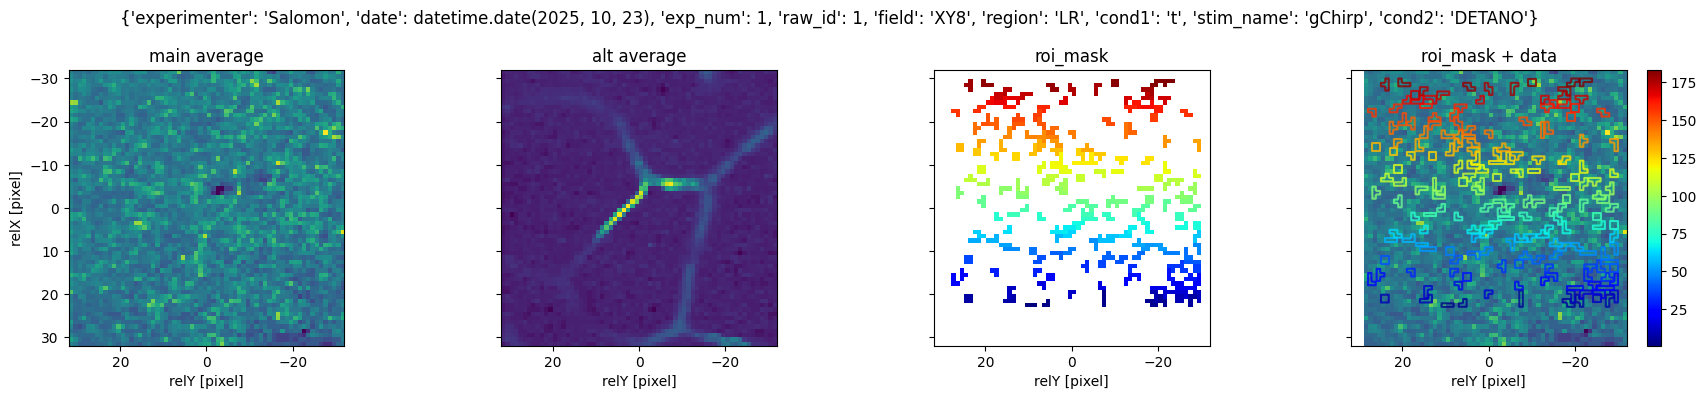

In [42]:
(RoiMask() & {"date": datetime.date(2025, 10, 23), "field": "XY8"}).plot1()

# Rois

In [43]:
Roi().populate(processes=20, display_progress=True)
Roi()

Processes: 100%|██████████| 2/2 [00:00<00:00,  3.67it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),roi_id integer id of each ROI,roi_size number of pixels in ROI,roi_size_um2 size of ROI in micrometers squared,"roi_dia_um diameter of ROI in micrometers, if it was a circle",artifact_flag flag if roi contains light artifact (1) or not (0)
Salomon,2025-05-26,1,1,XY3,LR,n,1,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,2,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,3,3,8.8623,3.35914,0
Salomon,2025-05-26,1,1,XY3,LR,n,4,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,5,3,8.8623,3.35914,0
Salomon,2025-05-26,1,1,XY3,LR,n,6,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,7,3,8.8623,3.35914,0
Salomon,2025-05-26,1,1,XY3,LR,n,8,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,9,4,11.8164,3.8788,0
Salomon,2025-05-26,1,1,XY3,LR,n,10,4,11.8164,3.8788,0


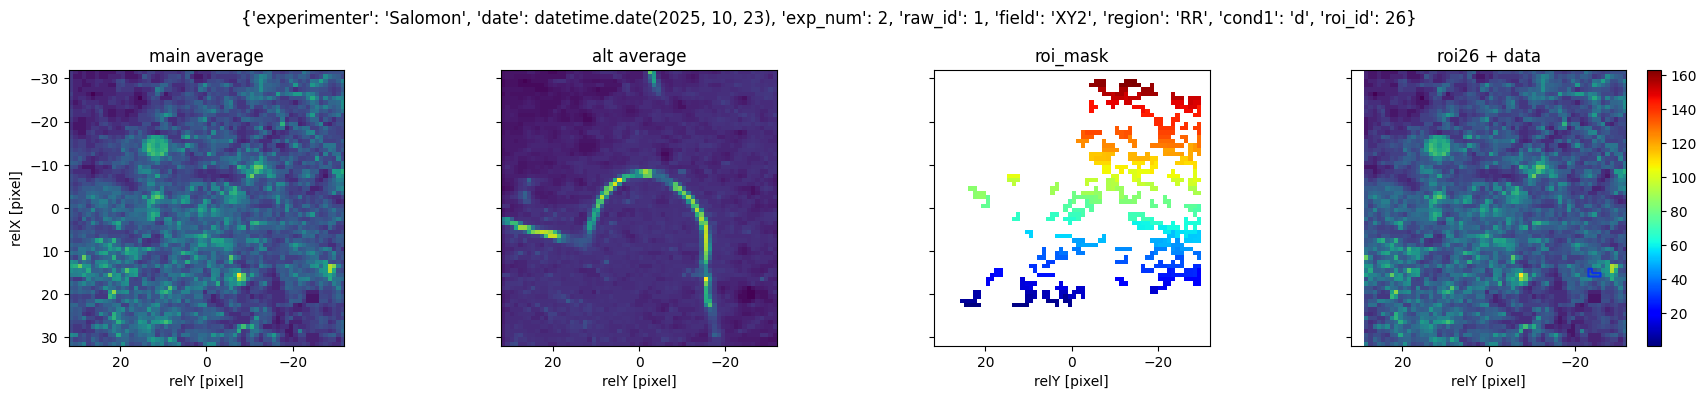

In [44]:
Roi().plot1(key=None)

### Traces

In [45]:
Traces().populate(processes=20, display_progress=True)
Traces()

Processes: 100%|██████████| 12/12 [00:03<00:00,  3.90it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,trace array of raw trace,trace_t0 numerical array of trace times,trace_dt time between frames,trace_valid Are values in trace correct (1) or not (0)?,trigger_valid Are triggertimes inside trace_times (1) or not (0)?
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,=BLOB=,0.018,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,=BLOB=,0.018,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,=BLOB=,0.018,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,=BLOB=,0.021,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,=BLOB=,0.018,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,6,=BLOB=,0.023,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,7,=BLOB=,0.022,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,8,=BLOB=,0.022,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,9,=BLOB=,0.021,0.128,1,1
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,10,=BLOB=,0.025,0.128,1,1


In [46]:
PreprocessParams().add_default(skip_duplicates=True)
PreprocessParams()

stim_name Unique string identifier,preprocess_id unique param set id,window_length window length for SavGol filter in seconds,poly_order order of polynomial for savgol filter,non_negative Clip negative values of trace,subtract_baseline Subtract baseline,"standardize standardize (1: with sd of baseline, 2: sd of trace, 0: nothing)","f_cutoff Cutoff frequency for low pass filter, only applied when > 0.","fs_resample Resampling frequency, only applied when > 0."
gChirp,1,60,3,0,1,1,0.0,0.0
lChirp,1,60,3,0,1,1,0.0,0.0
movingbar,1,60,3,0,1,1,0.0,0.0
noise,1,60,3,0,1,1,0.0,0.0
nostim,1,60,3,0,1,1,0.0,0.0


In [47]:
PreprocessTraces().populate(processes=20, display_progress=True)
PreprocessTraces()

Processes: 100%|██████████| 2244/2244 [00:02<00:00, 1071.78it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,pp_trace preprocessed trace,smoothed_trace output of savgol filter which is subtracted from the raw trace,pp_trace_t0 numerical array of trace times,pp_trace_dt time between frames
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,=BLOB=,=BLOB=,0.018,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,=BLOB=,=BLOB=,0.018,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,=BLOB=,=BLOB=,0.018,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,=BLOB=,=BLOB=,0.021,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,=BLOB=,=BLOB=,0.018,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,6,1,=BLOB=,=BLOB=,0.023,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,7,1,=BLOB=,=BLOB=,0.022,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,8,1,=BLOB=,=BLOB=,0.022,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,9,1,=BLOB=,=BLOB=,0.021,0.128
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,10,1,=BLOB=,=BLOB=,0.025,0.128


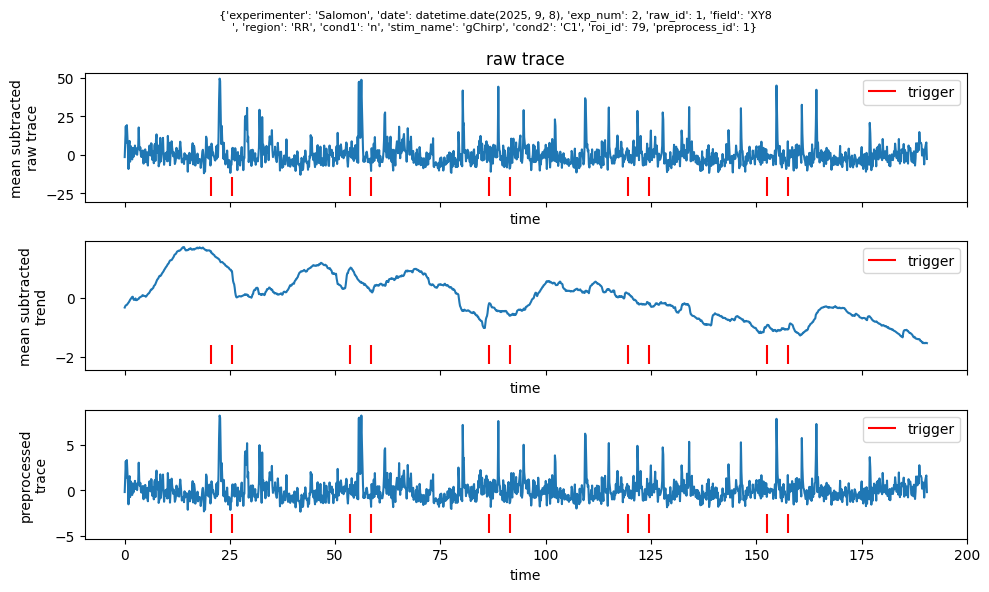

In [48]:
PreprocessTraces().plot1(key=None)

In [49]:
Snippets().populate(processes=20, display_progress=True)
Snippets()

Processes: 100%|██████████| 2244/2244 [00:01<00:00, 1249.33it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,snippets array of snippets (time x repetitions),"snippets_t0 array of snippet start times (repetitions, )",snippets_dt,triggertimes_snippets snippeted triggertimes (ntrigger_rep x repetitions),droppedlastrep_flag Was the last repetition incomplete and therefore dropped?
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,6,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,7,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,8,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,9,1,=BLOB=,=BLOB=,0.128,=BLOB=,0
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,10,1,=BLOB=,=BLOB=,0.128,=BLOB=,0


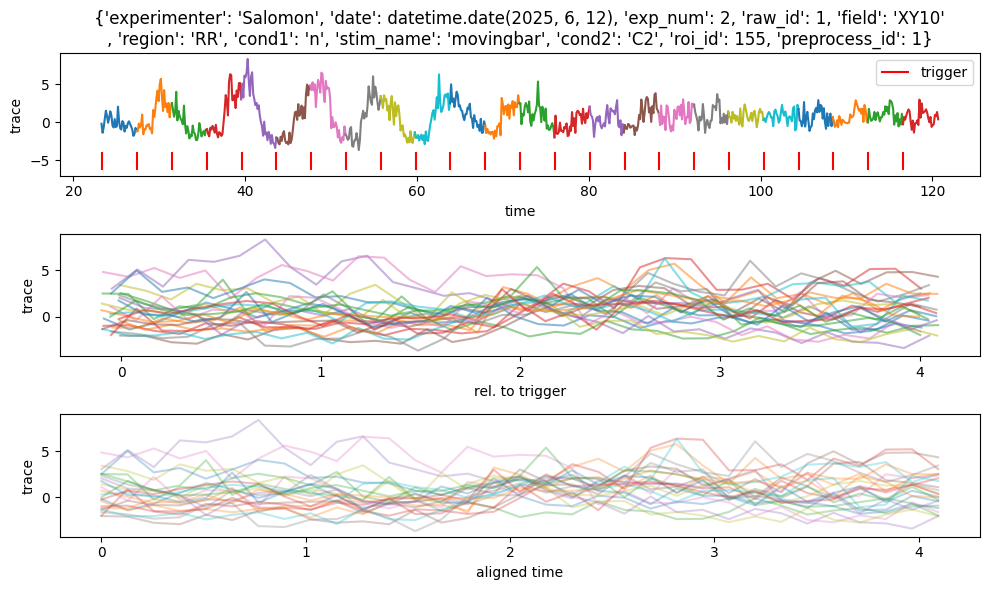

In [50]:
Snippets().plot1(key=None)

In [51]:
Averages().populate(processes=20, display_progress=True)
Averages()

Processes: 100%|██████████| 2244/2244 [00:08<00:00, 260.68it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


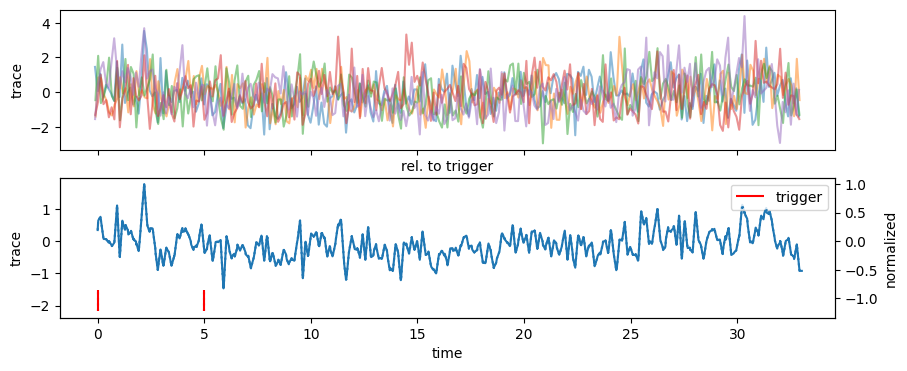

In [52]:
(Averages() & {"stim_name": "gChirp", "field": "XY8", "date": datetime.date(2025, 10, 23), "roi_id": 69, "cond2": "DETANO"}).plot1()

## Quality and statistics

In [18]:
ChirpQI().populate(display_progress=True, processes=20)
#ChirpQI() & {"stim_name": "gChirp", "field": "XY2", "date": datetime.date(2025, 10, 23)} & "qidx > 0.3"

Processes: 100%|██████████| 1052/1052 [00:00<00:00, 1728.01it/s]


{'success_count': 1052, 'error_list': []}

In [54]:
OsDsIndexes().populate(display_progress=True, processes=20)
OsDsIndexes()

/tmp/ipykernel_81837/1951177063.py:1: DeprecationWarning: OsDsIndexesTemplateV2 is deprecated. Use OsDsIndexesTemplate with _version=2 instead.
  OsDsIndexes().populate(display_progress=True, processes=20)
Processes: 100%|██████████| 748/748 [00:00<00:00, 982.14it/s] 
/tmp/ipykernel_81837/1951177063.py:2: DeprecationWarning: OsDsIndexesTemplateV2 is deprecated. Use OsDsIndexesTemplate with _version=2 instead.
  OsDsIndexes()


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,ds_index direction selectivity index as resulting vector length (absolute of projection on complex exponential),ds_pvalue p-value indicating the percentile of the vector length in null distribution,pref_dir preferred direction,os_index orientation selectivity index in analogy to ds_index,os_pvalue analogous to ds_pvalue for orientation tuning,pref_or preferred orientation,on_off on off index based on time kernel,d_qi quality index for moving bar response,dir_component,time_component,time_component_dt,surrogate_v computed by projecting on time,surrogate_dsi DSI of surrogate v
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,1,1,0.257711,0.47,-1.46939,0.301269,0.47,2.00489,-0.24,0.596243,=BLOB=,=BLOB=,0.128,=BLOB=,0.305492
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,2,1,0.314595,0.06,-1.85228,0.119472,0.56,0.245059,-0.33,0.764654,=BLOB=,=BLOB=,0.128,=BLOB=,0.310511
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,3,1,0.47076,0.0,-2.4298,0.0901835,0.79,2.04305,-0.72,0.654797,=BLOB=,=BLOB=,0.128,=BLOB=,0.363988
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,4,1,0.270836,0.1,-1.9452,0.209763,0.28,0.939792,-0.11,0.513283,=BLOB=,=BLOB=,0.128,=BLOB=,0.266774
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,5,1,0.492645,0.56,-1.22575,0.329828,0.13,2.21457,0.45,0.52846,=BLOB=,=BLOB=,0.128,=BLOB=,0.138685
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,6,1,0.208503,0.54,-1.41752,0.191897,0.64,1.03878,0.13,0.630613,=BLOB=,=BLOB=,0.128,=BLOB=,0.217317
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,7,1,0.181318,0.58,-0.874923,0.311513,0.32,0.904825,0.19,0.6282,=BLOB=,=BLOB=,0.128,=BLOB=,0.181177
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,8,1,0.358492,0.03,-2.25166,0.0700411,0.97,2.49771,-0.18,0.577675,=BLOB=,=BLOB=,0.128,=BLOB=,0.363924
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,9,1,0.133842,0.83,-1.9818,0.17654,0.77,0.0222022,0.06,0.554961,=BLOB=,=BLOB=,0.128,=BLOB=,0.110515
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,10,1,0.198733,0.26,-0.0888499,0.29726,0.17,0.608437,-0.0,0.661363,=BLOB=,=BLOB=,0.128,=BLOB=,0.249527


## Recording location

In [55]:
OpticDisk().populate(processes=20, display_progress=True)
OpticDisk()

Processes:   0%|          | 0/4 [00:00<?, ?it/s]/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/location/optic_disk.py:127: UserWarning: No optic disk information found for {'experimenter': 'Salomon', 'date': datetime.date(2025, 9, 8), 'exp_num': 2, 'raw_id': 1}
  warnings.warn(f'No optic disk information found for {key}')
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/utils/filesystem_utils.py:65: UserWarning: Error in file M1_RR_XY1_zstack.smp: File M1_RR_XY1_zstack.smp does not contain a valid stimulus field: {'field': 'zstack', 'stimulus': None, 'animal': 'M1', 'datatype': None, 'region': 'RR', 'cond1': 'XY1', 'cond2': None, 'cond3': None}
  warnings.warn(f"Error in file {filename}: {e}")
/gpfs01/euler/User/fsalomon/GitHub/djimaging/djimaging/tables/location/optic_disk.py:127: UserWarning: No optic disk information found for {'experimenter': 'Salomon', 'date': datetime.date(2025, 10, 23), 'exp_num': 1, 'raw_id': 1}
  warnings.warn(f'No optic disk information f

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,od_fromfile File from which optic disc data was extracted,odx XCoord_um relative to the optic disk,ody YCoord_um relative to the optic disk,odz ZCoord_um relative to the optic disk
Salomon,2025-05-26,1,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250526/1/Raw/M1_LR_n_od.smp,-496.36,-6751.8,-26979.0
Salomon,2025-06-12,2,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250612/2/Raw/M1_RR_n_od.smp,351.6,-7887.4,-27136.0
Salomon,2025-07-10,1,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250710/1/Raw/M1_LR_d_od.smp,-2688.3,-5187.4,-26898.0
Salomon,2025-07-10,2,1,/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250710/2/Raw/M1_RR_d_od.smp,-2749.3,-5403.2,-26926.0


In [56]:
RelativeFieldLocation().populate(processes=20, display_progress=True)
RelativeFieldLocation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),relx XCoord_um relative to the optic disk,rely YCoord_um relative to the optic disk,relz ZCoord_um relative to the optic disk
Salomon,2025-05-26,1,1,XY3,LR,n,182.64,-1258.7,-17.0
Salomon,2025-05-26,1,1,XY4,LR,n,182.64,-1258.7,-35.0
Salomon,2025-05-26,1,1,XY5,LR,v,264.68,-1418.5,-49.0
Salomon,2025-05-26,1,1,XY6,LR,v,264.68,-1418.5,-35.0
Salomon,2025-05-26,1,1,XY7,LR,t,-374.76,-1469.0,9.0
Salomon,2025-05-26,1,1,XY8,LR,t,-374.76,-1469.0,18.0
Salomon,2025-06-12,2,1,0-21-zoom,RR,n,-161.4,145.9,149.0
Salomon,2025-06-12,2,1,XY,RR,d,-1066.64,725.8,175.0
Salomon,2025-06-12,2,1,XY10,RR,n,-161.4,145.9,149.0
Salomon,2025-06-12,2,1,XY8,RR,t,-36.68,-383.6,159.0


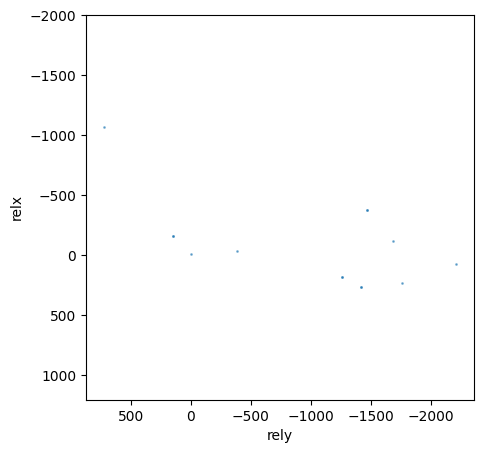

In [57]:
RelativeFieldLocation().plot()

In [58]:
RetinalFieldLocation().populate(processes=20, display_progress=True)
RetinalFieldLocation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),"ventral_dorsal_pos_um position on the ventral-dorsal axis, greater 0 means dorsal","temporal_nasal_pos_um position on the temporal-nasal axis, greater 0 means nasal"
Salomon,2025-05-26,1,1,XY3,LR,n,-182.64,1258.7
Salomon,2025-05-26,1,1,XY4,LR,n,-182.64,1258.7
Salomon,2025-05-26,1,1,XY5,LR,v,-264.68,1418.5
Salomon,2025-05-26,1,1,XY6,LR,v,-264.68,1418.5
Salomon,2025-05-26,1,1,XY7,LR,t,374.76,1469.0
Salomon,2025-05-26,1,1,XY8,LR,t,374.76,1469.0
Salomon,2025-06-12,2,1,0-21-zoom,RR,n,161.4,145.9
Salomon,2025-06-12,2,1,XY,RR,d,1066.64,725.8
Salomon,2025-06-12,2,1,XY10,RR,n,161.4,145.9
Salomon,2025-06-12,2,1,XY8,RR,t,36.68,-383.6


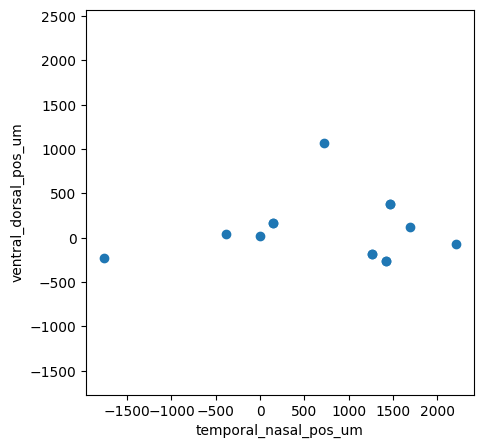

In [59]:
RetinalFieldLocation().plot()

# Clean up

If you are done with the tutorial you can delete (=drop) your schema again and create a schema with a more meaningful name than `ageuler_{username}_test`.

In [ ]:
if input("Continue with cleaning up? (yes/no))") != "yes":
    raise ValueError('Enter yes if you wish to continue.')

schema.drop()